# Figure Generation Pipeline
 
### Purpose
This notebook serves as the master execution script to calculate, format, and export all figures presented within the MSc dissertation. The output figures match the exact typographic and geometric standards of the native LaTeX report.

### Directory Architecture
* **Notebook Location:** `MSC-DISSERTATION-124/notebooks/figures.ipynb`
* **Target Output Directory:** `MSC-DISSERTATION-124/report/figures/` *(Auto-generated if non-existent)*

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Global path

OUTPUT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "report", "figures"))

In [4]:
# Academic typography settings

def apply_imperial_thesis_style():
    """
    Forces Matplotlib to render graphics matching standard LaTeX thesis typography.
    Standard A4 text width is approximately 5.8 inches.
    """
    plt.rcParams.update({
        # --- Native LaTeX Rendering ---
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "pgf.preamble": r"\usepackage{amsmath} \usepackage{amssymb}",
        
        # --- Standard A4 Dimensions ---
        "figure.figsize": [5.8, 4.2],  # Width, Height in inches
        "figure.dpi": 300,
        
        # --- Typography Scaling (10pt/11pt document body) ---
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "legend.fontsize": 8.5,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        
        # --- Structural Engineering Grid & Axes Aesthetics ---
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.linestyle": "-",
        "grid.linewidth": 0.4,
        "grid.color": "#B0B0B0",
        "grid.alpha": 0.5,
        
        # --- Tick Marks (Inside facing, standard PGFPlots style) ---
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        
        # --- Export Cleanliness ---
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.04
    })

apply_imperial_thesis_style()


---
## Chi-Lambdabar baseline bounds
**Objective:** Reproduce the classical textbook bilinear flexural buckling curve ($\chi$ against $\bar{\lambda}$) showing the distinct theoretical failure regimes: plastic squashing and Euler elastic buckling.

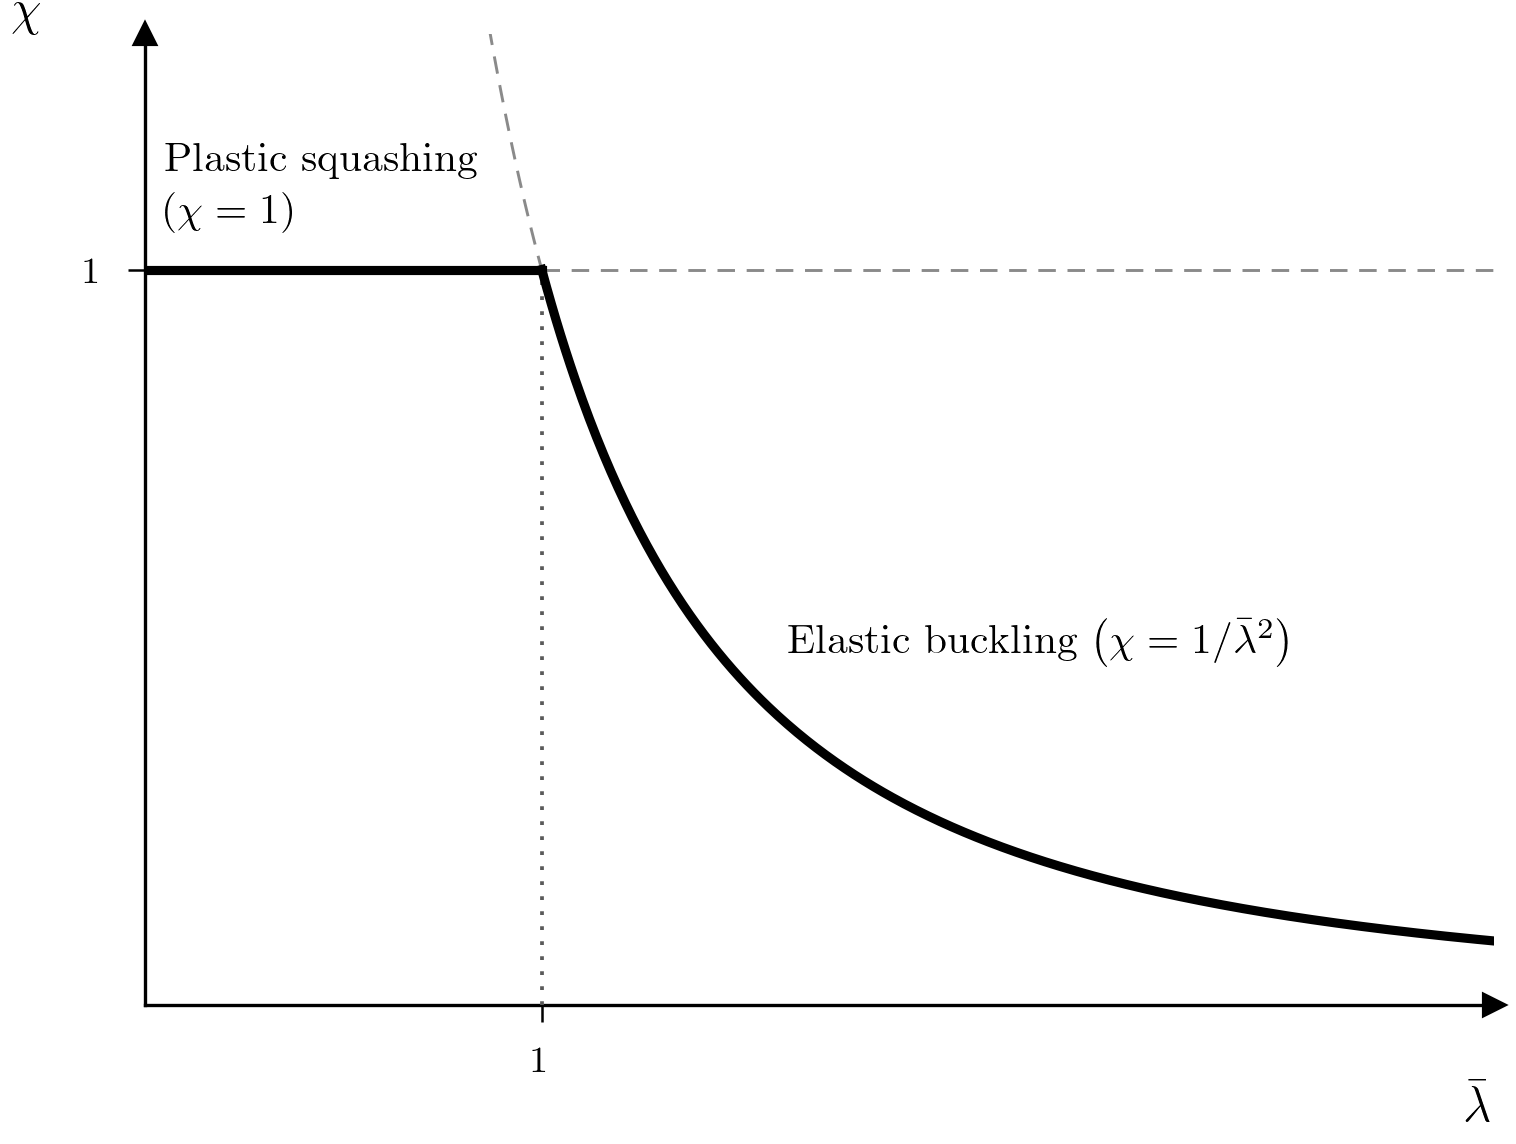

Exported to:
 -> c:\dev\MSc-Dissertation\MSc-Dissertation-124\report\figures\chi-lambdabar-baseline.pdf


In [12]:
# 1. Mathematical envelopes
lambda_squash = np.linspace(0.0, 1.0, 200)
chi_squash    = np.ones_like(lambda_squash)

lambda_buckle = np.linspace(1.0, 3.4, 400)
chi_buckle    = 1.0 / lambda_buckle**2

lambda_ext_up    = np.linspace(0.80, 1.0, 80)     # 1/lambda^2 continued above 1
chi_ext_up       = 1.0 / lambda_ext_up**2
lambda_ext_right = np.linspace(1.0, 3.4, 80)      # chi = 1 continued to the right
chi_ext_right    = np.ones_like(lambda_ext_right)

# 2. Canvas (figsize comes from the thesis style)
fig, ax = plt.subplots()

# Primary failure envelope (bold solid black)
ax.plot(lambda_squash, chi_squash, color="black", lw=2.2, zorder=5)
ax.plot(lambda_buckle, chi_buckle, color="black", lw=2.2, zorder=5)

# Faint construction tails crossing at (1, 1)
ax.plot(lambda_ext_up,    chi_ext_up,    color="#8a8a8a", ls=(0, (6, 4)), lw=0.7, zorder=3)
ax.plot(lambda_ext_right, chi_ext_right, color="#8a8a8a", ls=(0, (6, 4)), lw=0.7, zorder=3)

# Vertical projection at lambda = 1
ax.plot([1.0, 1.0], [0.0, 1.0], color="#5a5a5a", ls=(0, (1, 3)), lw=0.9, zorder=3)

# 3. Annotations (clear of every curve)
ax.text(0.05, 1.05, "Plastic squashing\n" + r"$(\chi = 1)$",
        ha="left", va="bottom", linespacing=1.4)
ax.text(1.62, 0.46, r"Elastic buckling $\left(\chi = 1/\bar{\lambda}^{2}\right)$",
        ha="left", va="bottom")

# 4. Axes, spines, ticks  (override the global grid + inward ticks for this schematic)
ax.set_xlim(0, 3.4)
ax.set_ylim(0, 1.32)

ax.set_xlabel(r"$\bar{\lambda}$", fontsize=12, loc="right", labelpad=2)
ax.set_ylabel(r"$\chi$",          fontsize=12, loc="top", rotation=0, labelpad=10)

ax.set_xticks([1.0]); ax.set_xticklabels([r"$1$"])
ax.set_yticks([1.0]); ax.set_yticklabels([r"$1$"])
ax.tick_params(direction="out", length=4, pad=6)   # outward ticks suit the arrow-axis look

ax.grid(False)                                      # clean quadrant, not a gridded plot
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

# CAD-style arrowheads at the open spine ends
ax.plot(1, 0, ls="", marker=">", ms=5, color="black",
        transform=ax.get_yaxis_transform(), clip_on=False, zorder=6)
ax.plot(0, 1, ls="", marker="^", ms=5, color="black",
        transform=ax.get_xaxis_transform(), clip_on=False, zorder=6)

# 5. Export (bbox / pad / dpi inherited from the thesis style)
fig1_path = os.path.join(OUTPUT_DIR, "chi-lambdabar-baseline.pdf")
plt.savefig(fig1_path)
plt.show()
print(f"Exported to:\n -> {fig1_path}")